In [10]:
import matplotlib.pyplot as plt

import torch
import torchvision.transforms.functional as L

from torch.optim import Adam
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import time
import unittest
import torch.nn.functional as F
import torch.nn as nn


In [11]:
def pytorch_coarse_grain_pix(tensor, cg):
    # Ensure the input tensor has the correct dimensions (layer, height, width)
    assert len(tensor.shape) == 3, "Input tensor should have dimensions (layer, height, width)"
    # Apply average pooling using torch.nn.functional.avg_pool2d
    pool_result = torch.nn.functional.avg_pool2d(
                tensor.unsqueeze(0),
                cg,
                stride = cg
                )
    
    # Squeeze the extra dimension and return the result
    return pool_result.squeeze(0)

def rescale_torch(tensor, cg):
    # Use interpolate to upsample the tensor using nearest neighbor mode
    upsampled_tensor = F.interpolate(
                     tensor.unsqueeze(0), 
                     scale_factor=cg,
                     mode='nearest').squeeze(0)

    return upsampled_tensor

def overlap_b2b (m1, m2, dim ):
    overlap = (1/dim**2) * torch.dot(m1.view(-1), m2.view(-1))# Calculate overlap
    return overlap


def structural_complexity (overlap_diff, overlap_k, overlap_kk):
    C = torch.abs (overlap_diff - 1/2 * (overlap_k + overlap_kk))   # Calculate defined structural complexity
    return C

In [12]:
def MSC (input_tensor):
        dim = len(input_tensor[0,:,0]) # Initialize dimensions and calculate the amount of steps to coarse grain
        cg = 2  
        times = 0
        layer = 3
        pro_dim = dim
        while pro_dim % cg == 0 :
            times+=1
            pro_dim = pro_dim / cg
        C = torch.zeros(times)
        
        # print(times)
        new_cg = cg
        for e in range (times):

            coarser_tensor = pytorch_coarse_grain_pix(input_tensor, cg)    # Calculate MSC in each step
            rescaled_tensor = rescale_torch(coarser_tensor, cg)

            overlap_diff = overlap_b2b( input_tensor, rescaled_tensor, dim )
            overlap_same = overlap_b2b (  input_tensor,  input_tensor, dim)
            overlap_same_plus = overlap_b2b ( rescaled_tensor, rescaled_tensor, dim)

            C[e] = structural_complexity (overlap_diff, overlap_same, overlap_same_plus)
            input_tensor = coarser_tensor
            dim = int(dim / cg)


        C_str = torch.sum (C)
        return C_str, C

In [13]:

# Define your custom measure function (C_str)
class CustomMeasure(nn.Module):
    def __init__(self):
        super(CustomMeasure, self).__init__()

    def forward(self, input_tensor):
        C_str, C = MSC (input_tensor)
        return C_str, C

In [19]:
def tensor_maker (image_path) :   # Preprocessing to get values on [0,1]
    image = Image.open(image_path)
    transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    tensor = transform(image)
    return tensor

In [20]:
def norm_meanstd(tensor):   # Normalization Constraint
    
    # Calculate mean and standard deviation
    tensor_mean = torch.mean(tensor)
    tensor_std = torch.std(tensor)
    norm_tensor = (tensor - tensor_mean)/tensor_std + torch.randn(1)
    
    return norm_tensor, tensor_mean,tensor_std

Step 0, Loss: -1.4999611377716064


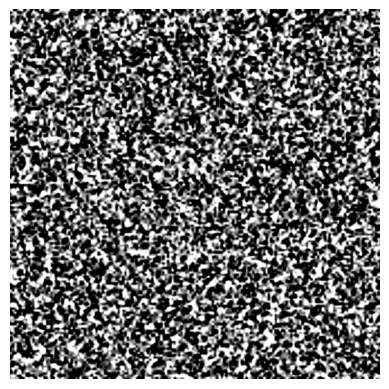

tensor([0.0356, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 50, Loss: -1.5000438690185547


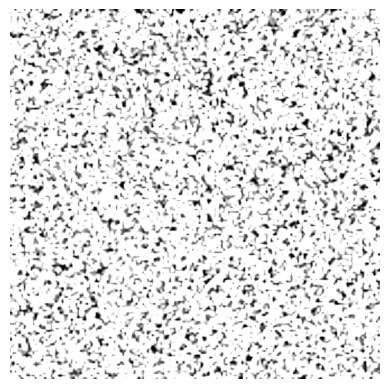

tensor([0.0357, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 100, Loss: -1.4999916553497314


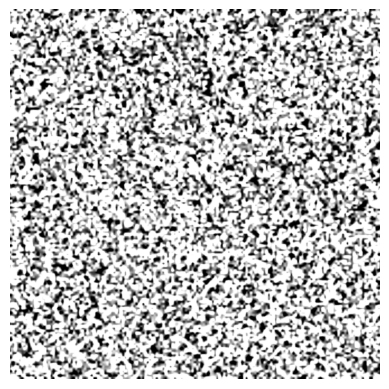

tensor([0.0356, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 150, Loss: -1.49998939037323


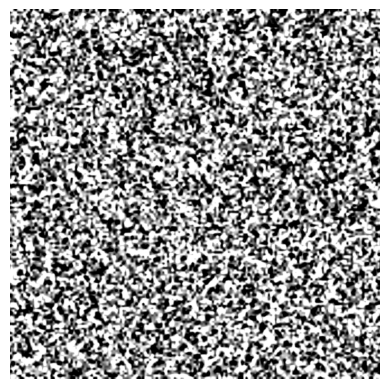

tensor([0.0356, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 200, Loss: -1.499980092048645


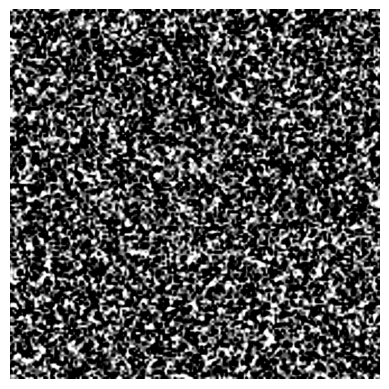

tensor([0.0356, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 250, Loss: -1.5000332593917847


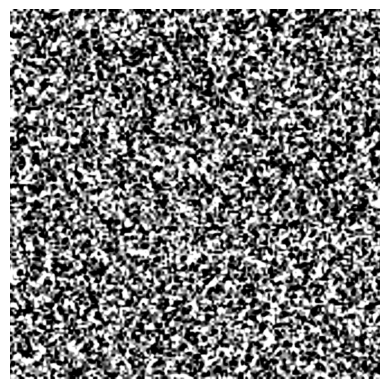

tensor([0.0357, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 300, Loss: -1.4999682903289795


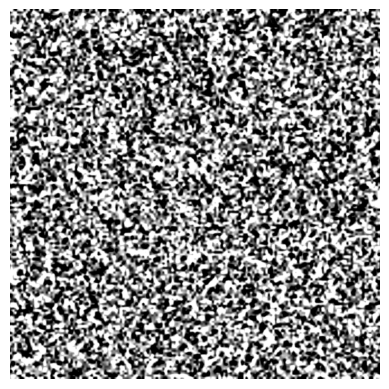

tensor([0.0356, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 350, Loss: -1.4999825954437256


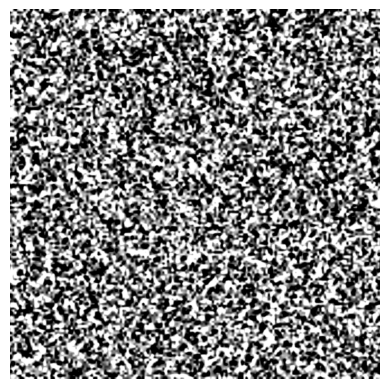

tensor([0.0356, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 400, Loss: -1.5000261068344116


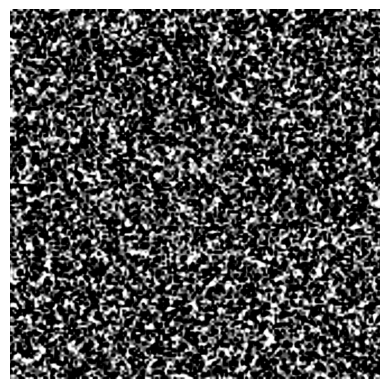

tensor([0.0357, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)
Step 450, Loss: -1.4999371767044067


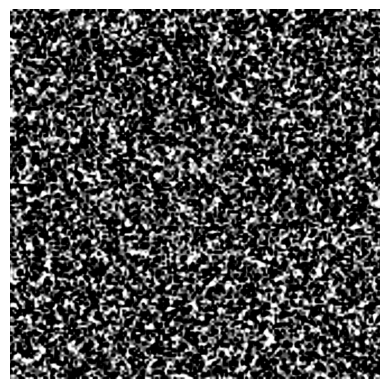

tensor([0.0356, 0.1239, 0.3385, 0.5117, 0.3401, 0.1098, 0.0317, 0.0065, 0.0014,
        0.0007], grad_fn=<CopySlices>)


In [21]:

image_path = r'C:\Users\vasni\Downloads\white_image(1).jpg'

input_tensor = tensor_maker(image_path)
custom_loss = CustomMeasure()
input_tensor = input_tensor.squeeze()# Ensure input_tensor requires gradients and is a leaf tensor
input_tensor = input_tensor.clone().detach().requires_grad_(True)



# Define the optimizer and move the input tensor to the appropriate device
optimizer = torch.optim.Adam([input_tensor], lr=0.01)

# Number of optimization steps
num_steps = 500

# input_tensor, m, n = norm_meanstd(input_tensor)
# input_tensor = input_tensor.clone().detach().requires_grad_(True)

# Perform optimization steps
for i in range(num_steps):
    
    input_tensor, m, n = norm_meanstd(input_tensor)    # Implement Constrain
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    
    
    optimizer.zero_grad()  # Clear previous gradients
    C_str, C = custom_loss(input_tensor)  # Calculate the custom measure
    loss = - C_str  # We want to maximize, so negate the custom measure


    torch.nn.utils.clip_grad_norm_(input_tensor, max_norm=1.0)
    
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update the input tensor to maximize the custom measure


    
    if i % 50== 0 :
        print(f'Step {i}, Loss: {loss.item()}')
        unnormalized_tensor = input_tensor.clone()  # Create a copy to avoid modifying the original tensor
        mean = torch.tensor([0.5, 0.5, 0.5])
        std = torch.tensor([0.5, 0.5, 0.5])
        reversed_normalized_image = unnormalized_tensor * std.view(1, 3, 1, 1) + mean.view(1, 3, 1, 1)

        # Clamp the pixel values to be in the [0, 1] range
        reversed_normalized_image = torch.clamp(reversed_normalized_image, 0, 1)
        # reversed_normalized_image = torch.clamp(unnormalized_tensor, 0, 1)

        # Display the image
        plt.imshow(L.to_pil_image(reversed_normalized_image.squeeze(0)))   
        plt.axis('off')
        plt.show()

        print(C)
